[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pmarcelino/mobillity-courses/blob/main/mobillity-univ/module-6-telling-the-story/notebook-6.1-structuring-a-data-story.ipynb)


# Structuring a data story - FGC evening service

This notebook takes a **verified analysis** and shapes it into a story you can present: **the result -> the main point -> the reasons -> the evidence** (Barbara Minto's pyramid). The finding is FGC's per-line evening-train service on a representative weekday (evening window **20:00-24:00**), computed and audited earlier in story-5.4 and carried forward here as the starting table.

## The verified analysis, carried forward

One row per FGC line, exactly as produced and validated in the story-5.4 audit (sorted shortest evening wait first). We start the story from this result - we do not re-run the analysis here.

In [1]:
"""The verified per-line evening-service table - carried forward, not recomputed.

Columns: line code, mode, evening departures, departures/hour, worst-direction wait (min).
"""
import pandas as pd

line_table = pd.DataFrame(
    [
        ("FV", "funicular", 80, 20.0, 6),
        ("L7", "metro", 56, 14.0, 9),
        ("L12", "metro", 45, 11.2, 11),
        ("L6", "metro", 39, 9.8, 13),
        ("S1", "rail", 25, 6.2, 24),
        ("S2", "rail", 25, 6.2, 24),
        ("L8", "metro", 16, 4.0, 34),
        ("R63", "rail", 3, 0.8, 80),
        ("S8", "rail", 14, 3.5, 80),
        ("R53", "rail", 2, 0.5, 120),
        ("S3", "rail", 5, 1.2, 120),
        ("S4", "rail", 4, 1.0, 120),
        ("R5", "rail", 7, 1.8, 240),
        ("R6", "rail", 6, 1.5, 240),
        ("RL1", "rail", 3, 0.8, 240),
    ],
    columns=["route_short_name", "mode", "evening_departures", "dep_per_hour", "evening_wait_min"],
)

table = line_table.copy()
print("PER-LINE EVENING SERVICE (representative weekday, 20:00-24:00)")
print(table.to_string(index=False))

PER-LINE EVENING SERVICE (representative weekday, 20:00-24:00)
route_short_name      mode  evening_departures  dep_per_hour  evening_wait_min
              FV funicular                  80          20.0                 6
              L7     metro                  56          14.0                 9
             L12     metro                  45          11.2                11
              L6     metro                  39           9.8                13
              S1      rail                  25           6.2                24
              S2      rail                  25           6.2                24
              L8     metro                  16           4.0                34
             R63      rail                   3           0.8                80
              S8      rail                  14           3.5                80
             R53      rail                   2           0.5               120
              S3      rail                   5           1.2        

## The main point & the reasons — checkable facts
Each `print` is one claim the lecture makes, stated as a labelled value.

In [2]:
t = table.set_index("route_short_name")

# Main point: evening service is very uneven across lines.
print("L7_EVENING_WAIT_MIN:", int(t.loc["L7", "evening_wait_min"]))      # busiest metro line
print("L7_EVENING_DEP_PER_HOUR:", t.loc["L7", "dep_per_hour"])
for ln in ["L6", "S1", "S2", "S4", "R5"]:
    print(f"{ln}_EVENING_WAIT_MIN:", int(t.loc[ln, "evening_wait_min"]))

# Reason 1 - the gap between lines is large.
print("BEST_DEP_PER_HOUR:", table.dep_per_hour.max(), "| WORST_DEP_PER_HOUR:", table.dep_per_hour.min())
print("OUTER_LINES_UNDER_2_PER_HOUR:", table.loc[table.dep_per_hour < 2, "route_short_name"].tolist())
print("LINES_WAIT_2H_PLUS:", table.loc[table.evening_wait_min >= 120, "route_short_name"].tolist())

# Reason 3 / evidence - all modes counted (metro, rail, funicular; no bus).
print("MODES_COUNTED:", sorted(table["mode"].unique()))

L7_EVENING_WAIT_MIN: 9
L7_EVENING_DEP_PER_HOUR: 14.0
L6_EVENING_WAIT_MIN: 13
S1_EVENING_WAIT_MIN: 24
S2_EVENING_WAIT_MIN: 24
S4_EVENING_WAIT_MIN: 120
R5_EVENING_WAIT_MIN: 240
BEST_DEP_PER_HOUR: 20.0 | WORST_DEP_PER_HOUR: 0.5
OUTER_LINES_UNDER_2_PER_HOUR: ['R63', 'R53', 'S3', 'S4', 'R5', 'R6', 'RL1']
LINES_WAIT_2H_PLUS: ['R53', 'S3', 'S4', 'R5', 'R6', 'RL1']
MODES_COUNTED: ['funicular', 'metro', 'rail']


## Visualize the unevenness
The bar chart the lecture's result slide depicts: minutes between evening trains, by line.

CHART_SAVED: story-6.1-evening-frequency.png
WAIT_RANGE_MIN: 6 to 240


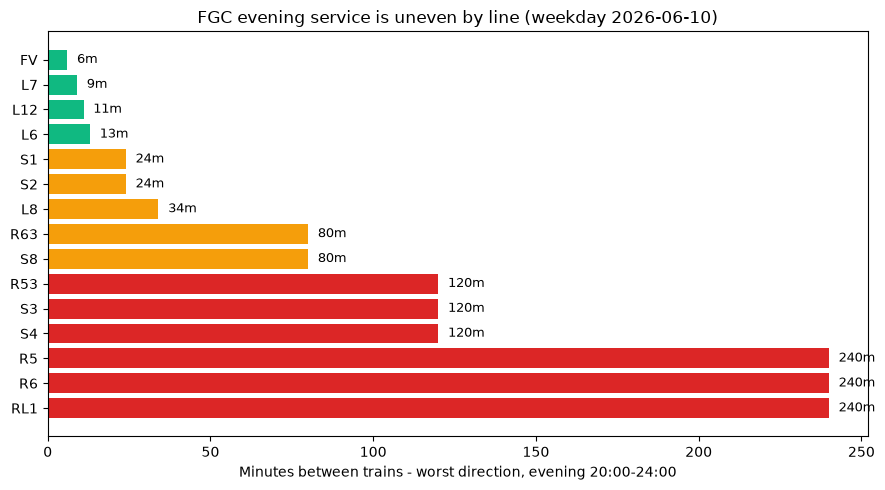

In [3]:
import matplotlib
import matplotlib.pyplot as plt

ch = table.sort_values("evening_wait_min")
colors = ["#10B981" if w <= 15 else "#F59E0B" if w < 120 else "#DC2626" for w in ch.evening_wait_min]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(ch.route_short_name, ch.evening_wait_min, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Minutes between trains - worst direction, evening 20:00-24:00")
ax.set_title("FGC evening service is uneven by line (weekday 2026-06-10)")
for i, w in enumerate(ch.evening_wait_min):
    ax.text(w + 3, i, f"{int(w)}m", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("story-6.1-evening-frequency.png", dpi=120)
print("CHART_SAVED: story-6.1-evening-frequency.png")
print("WAIT_RANGE_MIN:", int(ch.evening_wait_min.min()), "to", int(ch.evening_wait_min.max()))